# Predicting Employee Attrition Using Machine Learning
## 7005SCN Individual Research Project — CW2
**MSc Data Science | Coventry University**

---
### Project Overview
This notebook implements a complete machine learning pipeline to predict employee attrition using the IBM HR Analytics dataset. It covers:
1. Data Loading & Exploration
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing & SMOTE
4. Model Training & Comparison (Logistic Regression, Random Forest, XGBoost)
5. SHAP Interpretability Analysis
6. Model Fairness Evaluation
7. Results Summary

**Dataset Source:** IBM AI Fairness 360 GitHub Repository  
**Link:** https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv


## Step 1: Install & Import Libraries

In [ ]:
# !pip install xgboost shap imbalanced-learn scikit-learn pandas numpy matplotlib seaborn

import warnings
warnings.filterwarnings('ignore')

# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost
from xgboost import XGBClassifier

# SHAP
import shap

# Settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')
RANDOM_STATE = 42

print("All libraries imported successfully.")
print(f"pandas: {pd.__version__} | numpy: {np.__version__}")


All libraries imported successfully.
pandas: 2.2.2 | numpy: 2.0.2


## Step 2: Data Loading & Initial Inspection

In [ ]:
# Load IBM HR Analytics dataset from IBM's official GitHub repository
URL = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"

try:
    df = pd.read_csv(URL)
    print(f"Dataset loaded successfully from IBM GitHub.")
except Exception:
    # Fallback: load from local file if offline
    df = pd.read_csv("emp_attrition.csv")
    print("Dataset loaded from local file.")

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")


Dataset loaded successfully from IBM GitHub.
Shape: 1470 rows x 35 columns

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [ ]:
# First look at the data
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
# Dataset info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
# Statistical summary
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.92,9.14,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.49,403.51,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.19,8.11,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.91,1.02,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.00,0.00,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.87,602.02,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.72,1.09,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.89,20.33,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.73,0.71,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.06,1.11,1.0,1.00,2.0,3.00,5.0


In [ ]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

# Check target class distribution
print("\nTarget Variable (Attrition) Distribution:")
print(df['Attrition'].value_counts())
print(f"\nAttrition Rate: {df['Attrition'].value_counts(normalize=True)['Yes']:.1%}")


Missing values per column:
No missing values found.

Target Variable (Attrition) Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.1%


## Step 3: Exploratory Data Analysis (EDA)

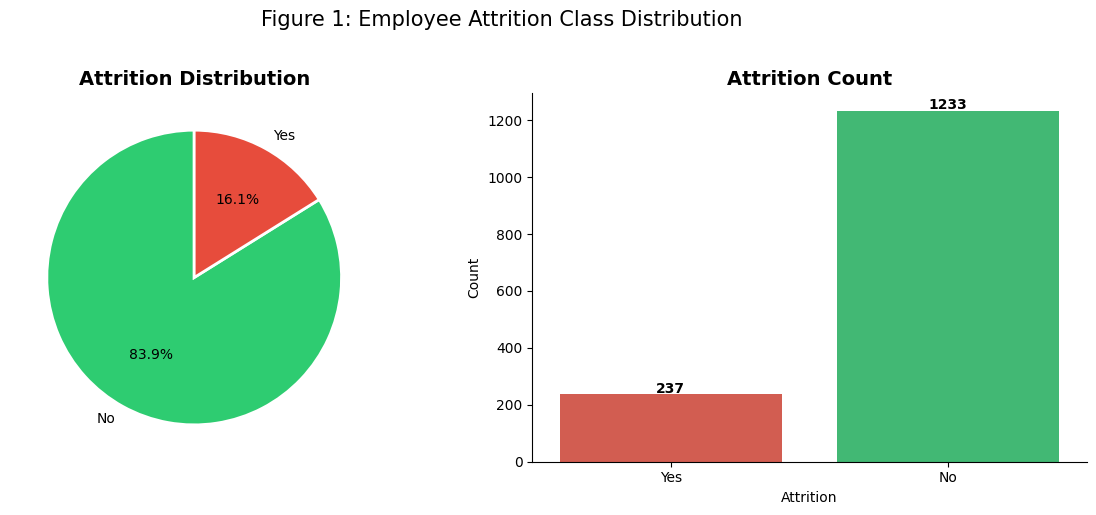

Class imbalance confirmed: ~16% attrition rate — SMOTE required.


In [ ]:
# Figure 1: Target class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
colors = ['#2ecc71', '#e74c3c']
counts = df['Attrition'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Attrition Distribution', fontsize=14, fontweight='bold')

# Bar chart
sns.countplot(data=df, x='Attrition', palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Attrition Count', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Count')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{int(bar.get_height())}', ha='center', fontweight='bold')

plt.suptitle('Figure 1: Employee Attrition Class Distribution', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('fig1_attrition_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("Class imbalance confirmed: ~16% attrition rate — SMOTE required.")


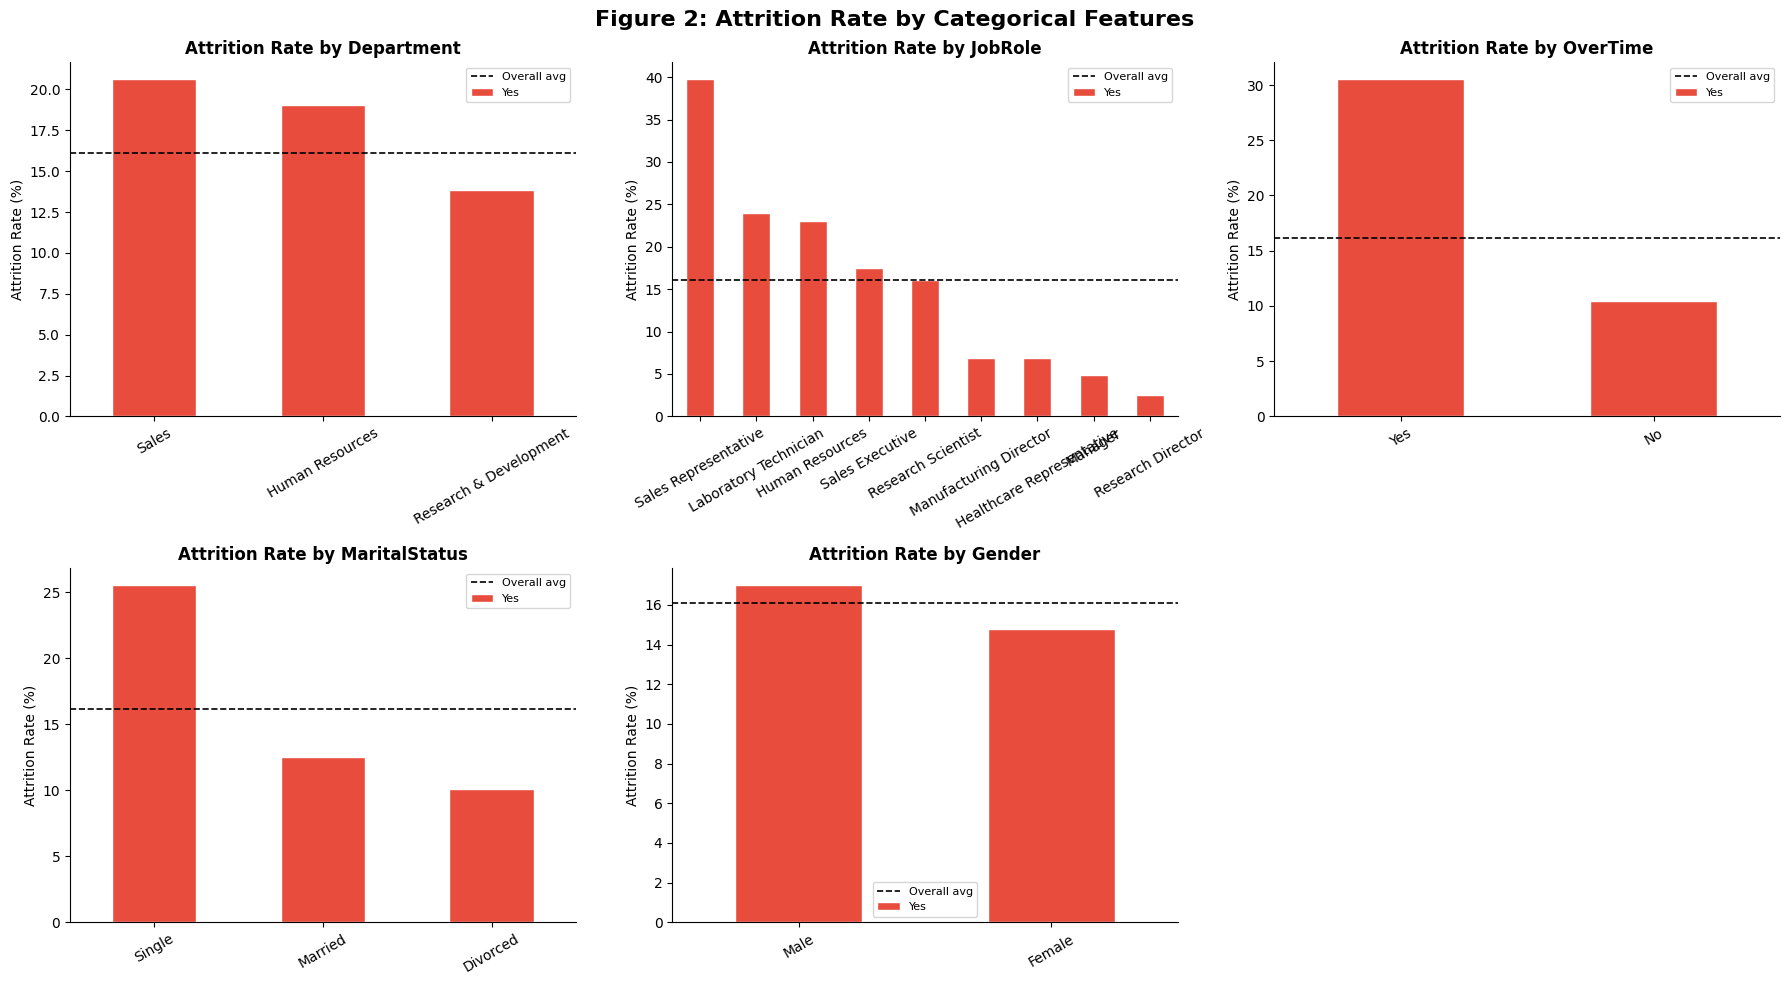

In [ ]:
# Figure 2: Attrition by key categorical features
cat_features = ['Department', 'JobRole', 'OverTime', 'MaritalStatus', 'Gender']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    ct = pd.crosstab(df[feat], df['Attrition'], normalize='index') * 100
    ct['Yes'].sort_values(ascending=False).plot(kind='bar', ax=axes[i],
        color='#e74c3c', edgecolor='white')
    axes[i].set_title(f'Attrition Rate by {feat}', fontweight='bold')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(y=df['Attrition'].value_counts(normalize=True)['Yes']*100,
                    color='black', linestyle='--', linewidth=1.2, label='Overall avg')
    axes[i].legend(fontsize=8)

axes[5].set_visible(False)
plt.suptitle('Figure 2: Attrition Rate by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_attrition_by_category.png', bbox_inches='tight', dpi=150)
plt.show()


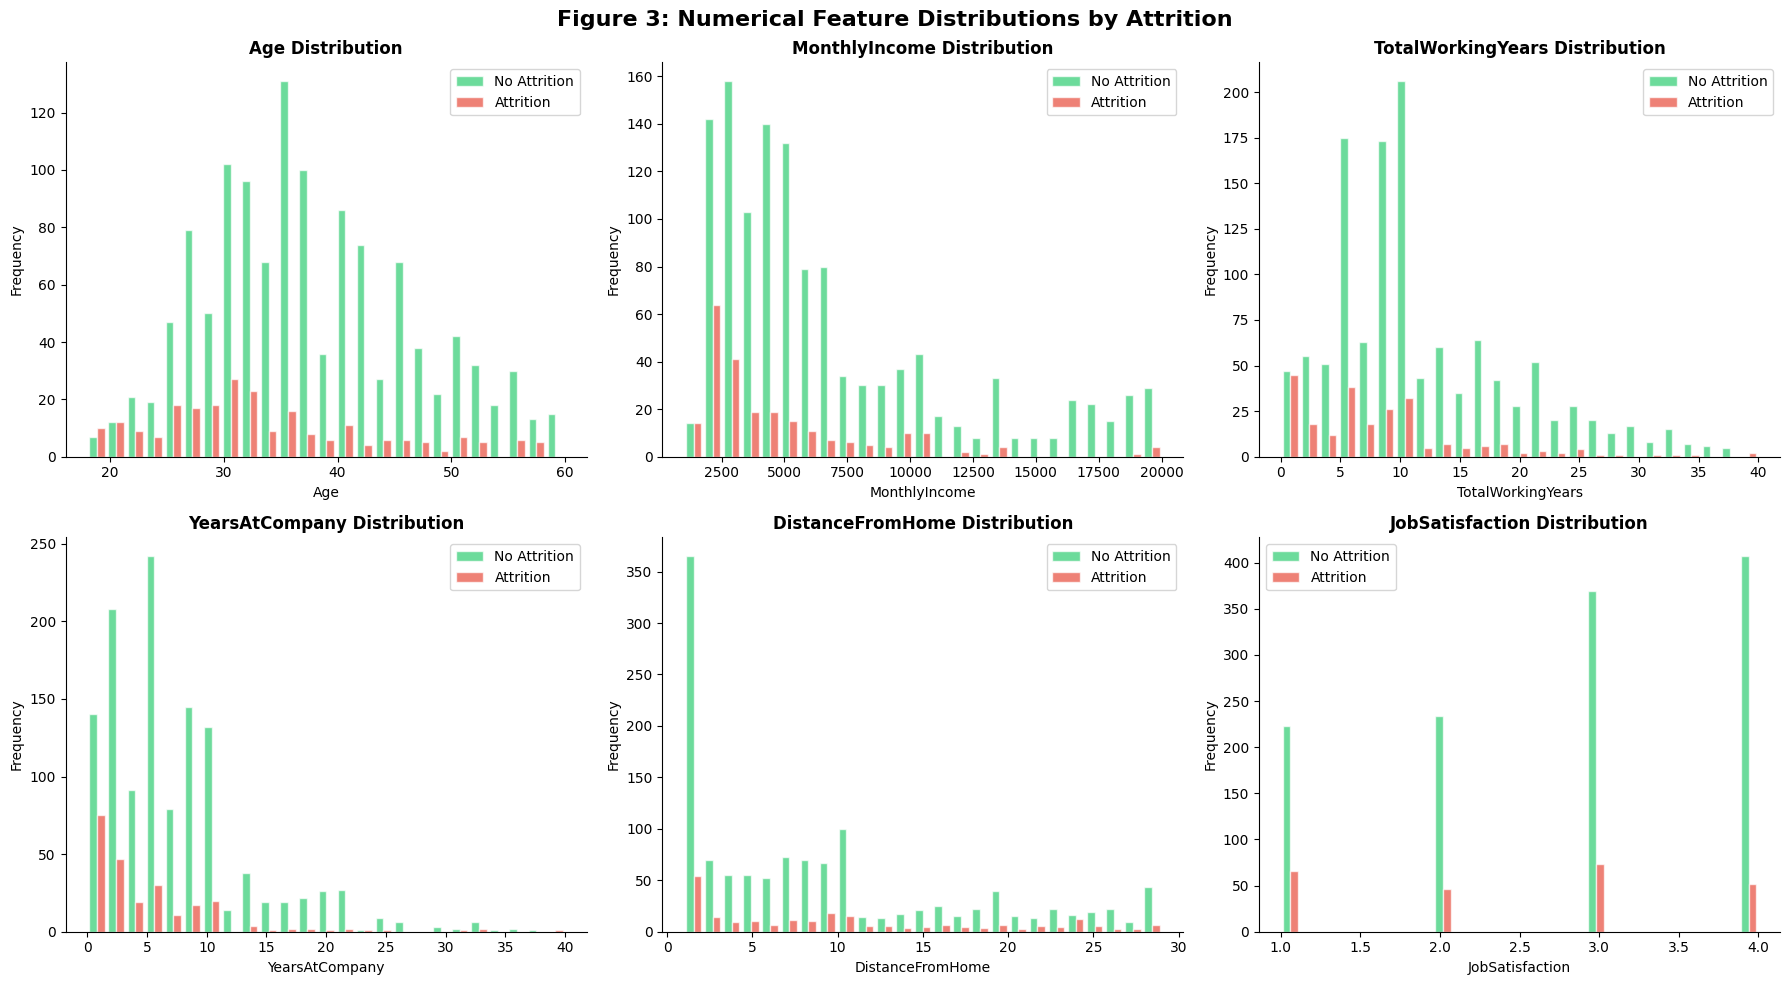

In [ ]:
# Figure 3: Numerical features by attrition
num_features = ['Age', 'MonthlyIncome', 'TotalWorkingYears',
                'YearsAtCompany', 'DistanceFromHome', 'JobSatisfaction']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    yes = df[df['Attrition'] == 'Yes'][feat]
    no  = df[df['Attrition'] == 'No'][feat]
    axes[i].hist([no, yes], bins=25, label=['No Attrition', 'Attrition'],
                 color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='white')
    axes[i].set_title(f'{feat} Distribution', fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Figure 3: Numerical Feature Distributions by Attrition', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_numerical_distributions.png', bbox_inches='tight', dpi=150)
plt.show()


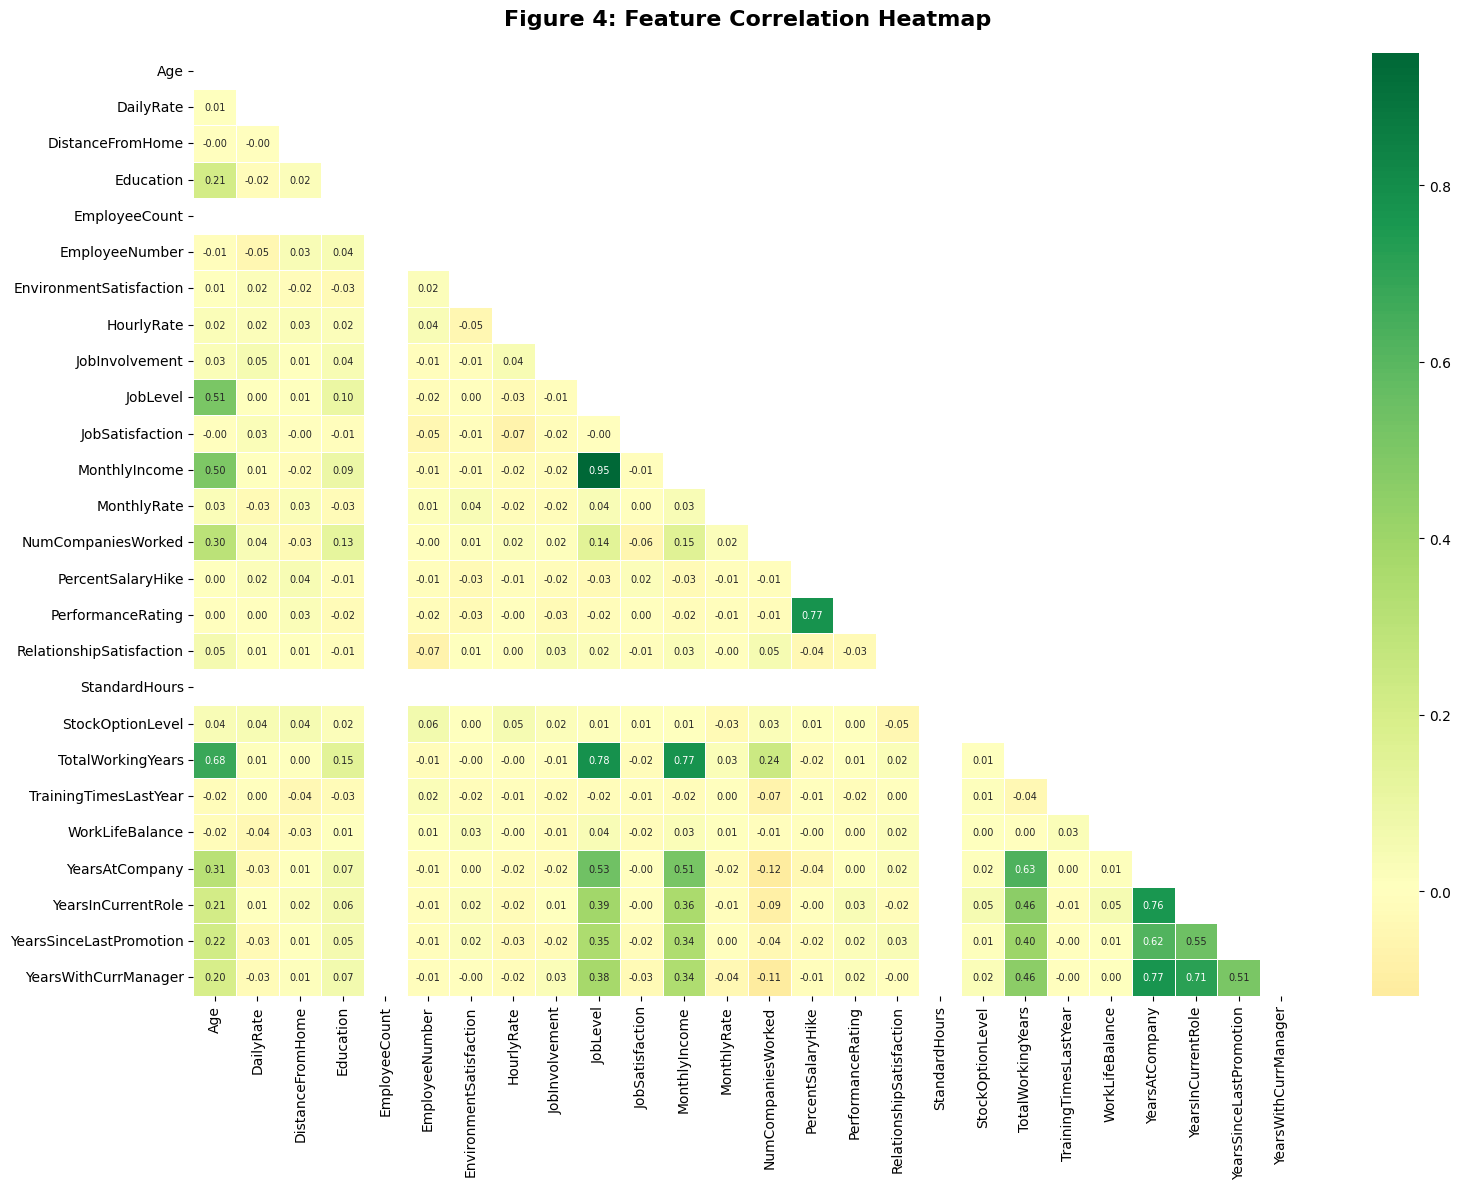

In [ ]:
# Figure 4: Correlation heatmap (numeric only)
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Figure 4: Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


## Step 4: Data Preprocessing

In [ ]:
# Preprocessing pipeline

# 1. Drop constant/ID columns (no predictive value)
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_clean = df.drop(columns=cols_to_drop)
print(f"Dropped constant columns: {cols_to_drop}")

# 2. Encode target variable
df_clean['Attrition'] = (df_clean['Attrition'] == 'Yes').astype(int)

# 3. Encode categorical features
le = LabelEncoder()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns to encode: {cat_cols}")

for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

print("\nLabel encoding applied to all categorical columns.")

# 4. Separate features and target
X = df_clean.drop('Attrition', axis=1)
y = df_clean['Attrition']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
print(f"Positive class (attrition=1): {y.sum()} ({y.mean():.1%})")


Dropped constant columns: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Label encoding applied to all categorical columns.

Feature matrix shape: (1470, 30)
Target vector shape:  (1470,)
Positive class (attrition=1): 237 (16.1%)


In [ ]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")
print(f"Train attrition rate: {y_train.mean():.1%}")
print(f"Test attrition rate:  {y_test.mean():.1%}")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("\nFeature scaling applied (StandardScaler).")


Training set:   1176 samples
Test set:       294 samples
Train attrition rate: 16.2%
Test attrition rate:  16.0%

Feature scaling applied (StandardScaler).


SMOTE Applied:
Before SMOTE — Class 0: 986 | Class 1: 190
After  SMOTE — Class 0: 986 | Class 1: 986


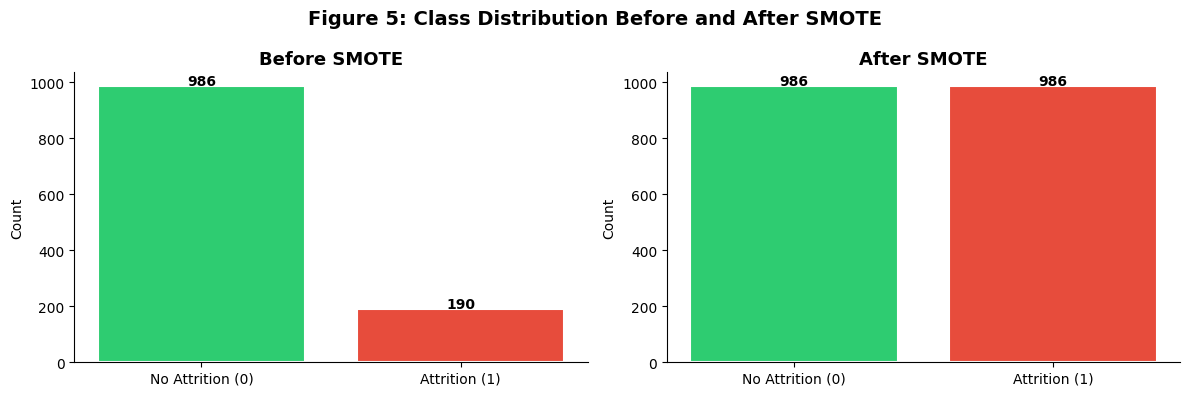

In [ ]:
# Apply SMOTE to training set only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("SMOTE Applied:")
print(f"Before SMOTE — Class 0: {(y_train==0).sum()} | Class 1: {(y_train==1).sum()}")
print(f"After  SMOTE — Class 0: {(y_train_sm==0).sum()} | Class 1: {(y_train_sm==1).sum()}")

# Visualise SMOTE effect
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (y_data, title) in zip(axes, [(y_train, 'Before SMOTE'), (y_train_sm, 'After SMOTE')]):
    counts = pd.Series(y_data).value_counts().sort_index()
    bars = ax.bar(['No Attrition (0)', 'Attrition (1)'], counts.values,
                  color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                str(int(bar.get_height())), ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_ylabel('Count')

plt.suptitle('Figure 5: Class Distribution Before and After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_smote_effect.png', bbox_inches='tight', dpi=150)
plt.show()


## Step 5: Model Training & Evaluation

In [ ]:
# Helper: evaluate a model
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    results = {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_te, y_pred),  4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall':    round(recall_score(y_te, y_pred),    4),
        'F1-Score':  round(f1_score(y_te, y_pred),        4),
        'AUC-ROC':   round(roc_auc_score(y_te, y_proba),  4),
    }
    return results, model, y_pred, y_proba

results_list = []
trained_models = {}

In [ ]:
# Model 1: Logistic Regression (Baseline)
# Before SMOTE
lr_before = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=0.1)
res_lr_before, lr_fitted_before, y_pred_lr_before, y_proba_lr_before = evaluate_model(
    'Logistic Regression (Before SMOTE)', lr_before, X_train_scaled, y_train, X_test_scaled, y_test)
results_list.append(res_lr_before)
trained_models['Logistic Regression (Before SMOTE)'] = (lr_fitted_before, y_pred_lr_before, y_proba_lr_before)
print("Logistic Regression (Before SMOTE) Results:")
for k, v in res_lr_before.items():
    print(f"  {k}: {v}")

# After SMOTE
lr_after = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=0.1)
res_lr_after, lr_fitted_after, y_pred_lr_after, y_proba_lr_after = evaluate_model(
    'Logistic Regression (After SMOTE)', lr_after, X_train_sm, y_train_sm, X_test_scaled, y_test)
results_list.append(res_lr_after)
trained_models['Logistic Regression (After SMOTE)'] = (lr_fitted_after, y_pred_lr_after, y_proba_lr_after)
print("\nLogistic Regression (After SMOTE) Results:")
for k, v in res_lr_after.items():
    print(f"  {k}: {v}")

Logistic Regression (Before SMOTE) Results:
  Model: Logistic Regression (Before SMOTE)
  Accuracy: 0.8776
  Precision: 0.7391
  Recall: 0.3617
  F1-Score: 0.4857
  AUC-ROC: 0.8064

Logistic Regression (After SMOTE) Results:
  Model: Logistic Regression (After SMOTE)
  Accuracy: 0.7585
  Precision: 0.375
  Recall: 0.766
  F1-Score: 0.5035
  AUC-ROC: 0.8056


In [ ]:
# Model 2: Random Forest
# Hyperparameter tuning with GridSearchCV
rf_params = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
}

# Before SMOTE
rf_grid_before = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_params, cv=5, scoring='f1', n_jobs=-1, verbose=0)
rf_grid_before.fit(X_train_scaled, y_train)
best_rf_before = rf_grid_before.best_estimator_
print(f"Best RF params (Before SMOTE): {rf_grid_before.best_params_}")

res_rf_before, rf_fitted_before, y_pred_rf_before, y_proba_rf_before = evaluate_model(
    'Random Forest (Before SMOTE)', best_rf_before, X_train_scaled, y_train, X_test_scaled, y_test)
results_list.append(res_rf_before)
trained_models['Random Forest (Before SMOTE)'] = (rf_fitted_before, y_pred_rf_before, y_proba_rf_before)
print("Random Forest (Before SMOTE) Results:")
for k, v in res_rf_before.items():
    print(f"  {k}: {v}")

# After SMOTE
rf_grid_after = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_params, cv=5, scoring='f1', n_jobs=-1, verbose=0)
rf_grid_after.fit(X_train_sm, y_train_sm)
best_rf_after = rf_grid_after.best_estimator_
print(f"\nBest RF params (After SMOTE): {rf_grid_after.best_params_}")

res_rf_after, rf_fitted_after, y_pred_rf_after, y_proba_rf_after = evaluate_model(
    'Random Forest (After SMOTE)', best_rf_after, X_train_sm, y_train_sm, X_test_scaled, y_test)
results_list.append(res_rf_after)
trained_models['Random Forest (After SMOTE)'] = (rf_fitted_after, y_pred_rf_after, y_proba_rf_after)
print("Random Forest (After SMOTE) Results:")
for k, v in res_rf_after.items():
    print(f"  {k}: {v}")

Best RF params (Before SMOTE): {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Random Forest (Before SMOTE) Results:
  Model: Random Forest (Before SMOTE)
  Accuracy: 0.8401
  Precision: 0.5
  Recall: 0.1064
  F1-Score: 0.1754
  AUC-ROC: 0.7871

Best RF params (After SMOTE): {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest (After SMOTE) Results:
  Model: Random Forest (After SMOTE)
  Accuracy: 0.8537
  Precision: 0.5909
  Recall: 0.2766
  F1-Score: 0.3768
  AUC-ROC: 0.8045


In [ ]:
# Model 3: XGBoost
xgb_params = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 6],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0],
}

# Before SMOTE
xgb_grid_before = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False),
    xgb_params, cv=5, scoring='f1', n_jobs=-1, verbose=0)
xgb_grid_before.fit(X_train_scaled, y_train)
best_xgb_before = xgb_grid_before.best_estimator_
print(f"Best XGB params (Before SMOTE): {xgb_grid_before.best_params_}")

res_xgb_before, xgb_fitted_before, y_pred_xgb_before, y_proba_xgb_before = evaluate_model(
    'XGBoost (Before SMOTE)', best_xgb_before, X_train_scaled, y_train, X_test_scaled, y_test)
results_list.append(res_xgb_before)
trained_models['XGBoost (Before SMOTE)'] = (xgb_fitted_before, y_pred_xgb_before, y_proba_xgb_before)
print("XGBoost (Before SMOTE) Results:")
for k, v in res_xgb_before.items():
    print(f"  {k}: {v}")

# After SMOTE
xgb_grid_after = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False),
    xgb_params, cv=5, scoring='f1', n_jobs=-1, verbose=0)
xgb_grid_after.fit(X_train_sm, y_train_sm)
best_xgb_after = xgb_grid_after.best_estimator_
print(f"\nBest XGB params (After SMOTE): {xgb_grid_after.best_params_}")

res_xgb_after, xgb_fitted_after, y_pred_xgb_after, y_proba_xgb_after = evaluate_model(
    'XGBoost (After SMOTE)', best_xgb_after, X_train_sm, y_train_sm, X_test_scaled, y_test)
results_list.append(res_xgb_after)
trained_models['XGBoost (After SMOTE)'] = (xgb_fitted_after, y_pred_xgb_after, y_proba_xgb_after)
print("XGBoost (After SMOTE) Results:")
for k, v in res_xgb_after.items():
    print(f"  {k}: {v}")

Best XGB params (Before SMOTE): {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
XGBoost (Before SMOTE) Results:
  Model: XGBoost (Before SMOTE)
  Accuracy: 0.8673
  Precision: 0.75
  Recall: 0.2553
  F1-Score: 0.381
  AUC-ROC: 0.8022

Best XGB params (After SMOTE): {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
XGBoost (After SMOTE) Results:
  Model: XGBoost (After SMOTE)
  Accuracy: 0.8503
  Precision: 0.5652
  Recall: 0.2766
  F1-Score: 0.3714
  AUC-ROC: 0.8122


In [ ]:
# Comparison Table
results_df = pd.DataFrame(results_list).set_index('Model')
print("\n=== MODEL COMPARISON ===")
print(results_df.to_string())

# Identify best model
best_model_name = results_df['AUC-ROC'].idxmax()
print(f"\nBest Model (by AUC-ROC): {best_model_name} — AUC-ROC = {results_df.loc[best_model_name, 'AUC-ROC']}")


=== MODEL COMPARISON ===
                                    Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                                             
Logistic Regression (Before SMOTE)    0.8776     0.7391  0.3617    0.4857   0.8064
Logistic Regression (After SMOTE)     0.7585     0.3750  0.7660    0.5035   0.8056
Random Forest (Before SMOTE)          0.8401     0.5000  0.1064    0.1754   0.7871
Random Forest (After SMOTE)           0.8537     0.5909  0.2766    0.3768   0.8045
XGBoost (Before SMOTE)                0.8673     0.7500  0.2553    0.3810   0.8022
XGBoost (After SMOTE)                 0.8503     0.5652  0.2766    0.3714   0.8122

Best Model (by AUC-ROC): XGBoost (After SMOTE) — AUC-ROC = 0.8122


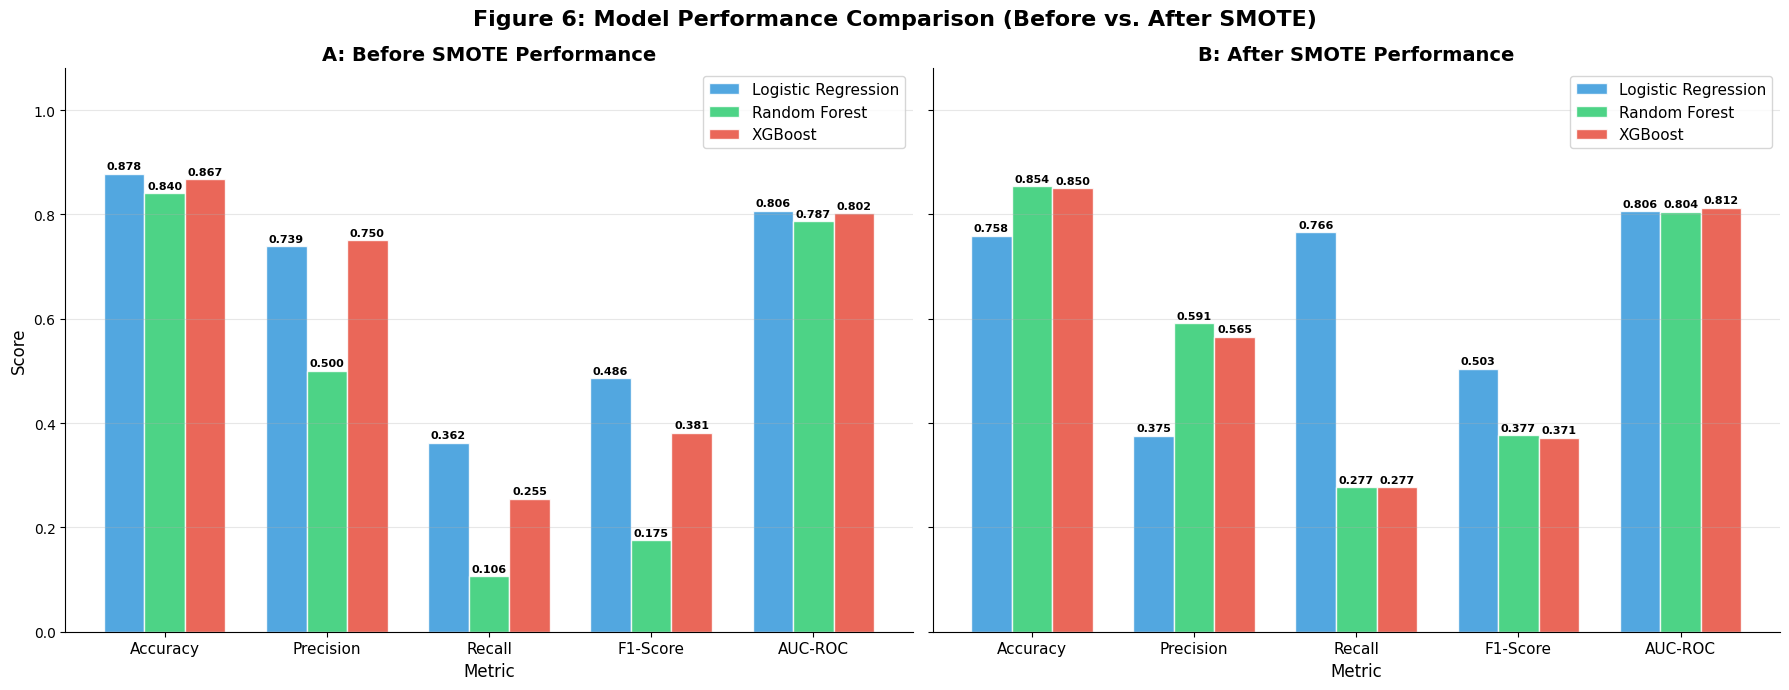

In [ ]:
# Figure 6: Model comparison bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.25
colors = ['#3498db', '#2ecc71', '#e74c3c']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Before SMOTE models
models_before = ['Logistic Regression (Before SMOTE)', 'Random Forest (Before SMOTE)', 'XGBoost (Before SMOTE)']
for i, (model_name, color) in enumerate(zip(models_before, colors)):
    vals = results_df.loc[model_name, metrics].values.astype(float)
    short_name = model_name.split(' (')[0]
    bars = ax1.bar(x + i*width, vals, width, label=short_name, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax1.set_xlabel('Metric', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('A: Before SMOTE Performance', fontsize=14, fontweight='bold')
ax1.set_xticks(x + width)
ax1.set_xticklabels(metrics, fontsize=11)
ax1.set_ylim(0, 1.08)
ax1.legend(fontsize=11)
ax1.grid(True, axis='y', alpha=0.3)

# After SMOTE models
models_after = ['Logistic Regression (After SMOTE)', 'Random Forest (After SMOTE)', 'XGBoost (After SMOTE)']
for i, (model_name, color) in enumerate(zip(models_after, colors)):
    vals = results_df.loc[model_name, metrics].values.astype(float)
    short_name = model_name.split(' (')[0]
    bars = ax2.bar(x + i*width, vals, width, label=short_name, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax2.set_xlabel('Metric', fontsize=12)
ax2.set_title('B: After SMOTE Performance', fontsize=14, fontweight='bold')
ax2.set_xticks(x + width)
ax2.set_xticklabels(metrics, fontsize=11)
ax2.legend(fontsize=11)
ax2.grid(True, axis='y', alpha=0.3)

plt.suptitle('Figure 6: Model Performance Comparison (Before vs. After SMOTE)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

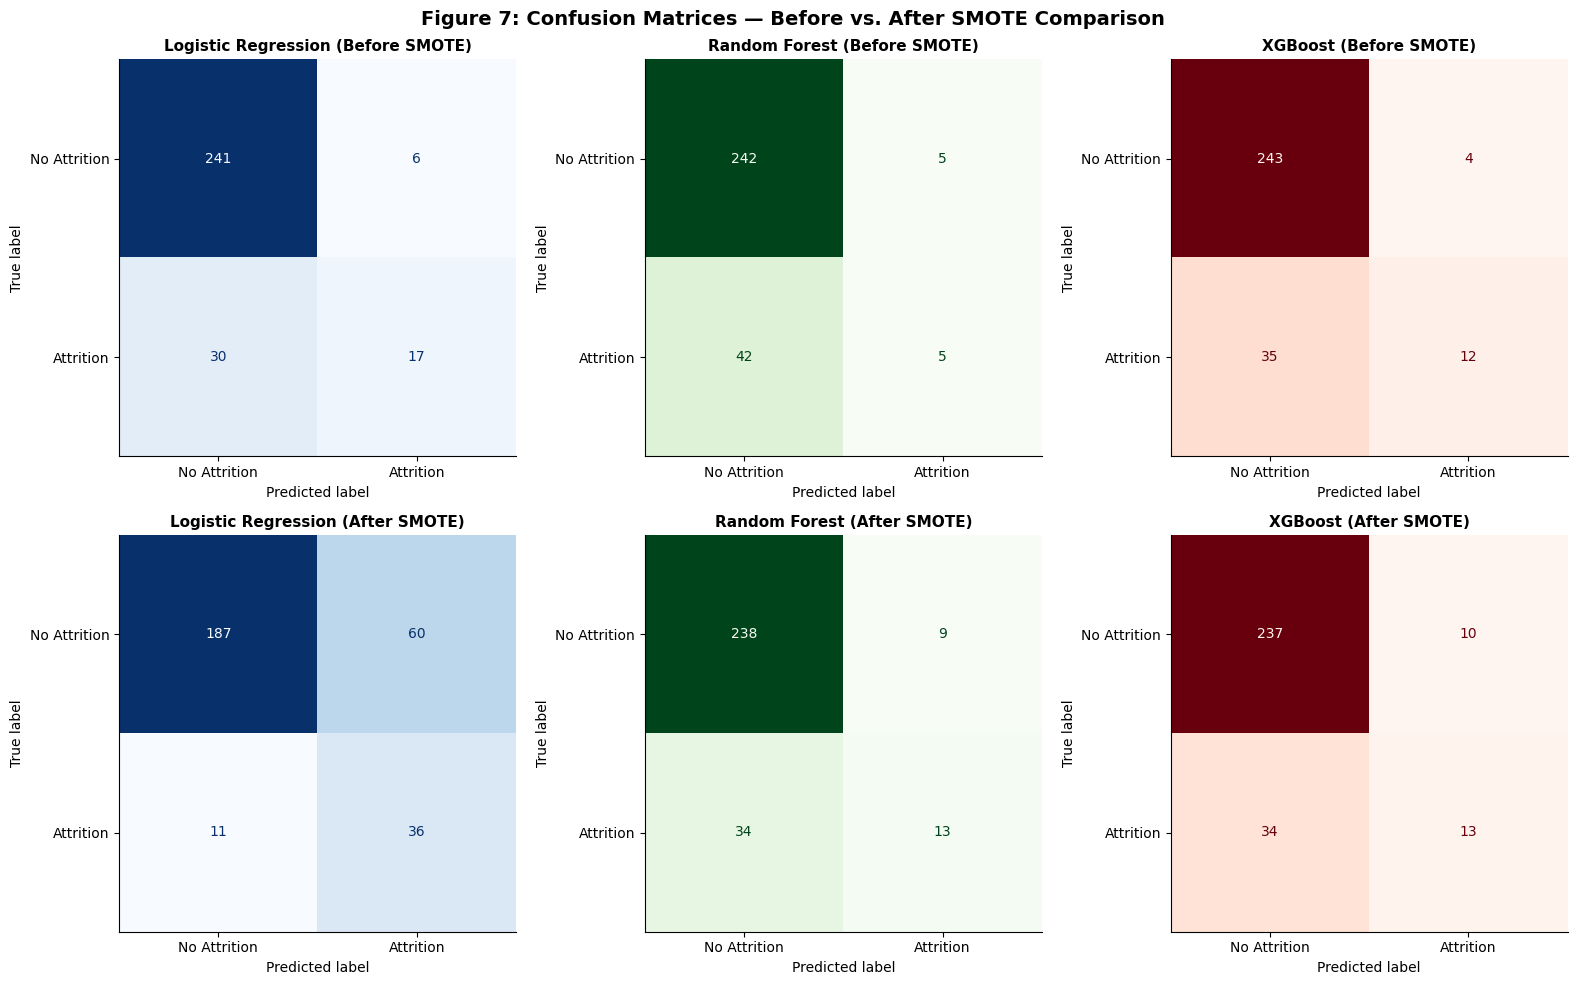

In [ ]:
# Figure 7: Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
model_names_before = ['Logistic Regression (Before SMOTE)', 'Random Forest (Before SMOTE)', 'XGBoost (Before SMOTE)']
model_names_after = ['Logistic Regression (After SMOTE)', 'Random Forest (After SMOTE)', 'XGBoost (After SMOTE)']
cmaps = ['Blues', 'Greens', 'Reds']

# Before SMOTE Confusion Matrices
for i, (name, cmap) in enumerate(zip(model_names_before, cmaps)):
    ax = axes[0, i]
    _, y_pred, _ = trained_models[name]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Attrition', 'Attrition'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'{name}', fontweight='bold', fontsize=11)

# After SMOTE Confusion Matrices
for i, (name, cmap) in enumerate(zip(model_names_after, cmaps)):
    ax = axes[1, i]
    _, y_pred, _ = trained_models[name]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Attrition', 'Attrition'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'{name}', fontweight='bold', fontsize=11)

plt.suptitle('Figure 7: Confusion Matrices — Before vs. After SMOTE Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

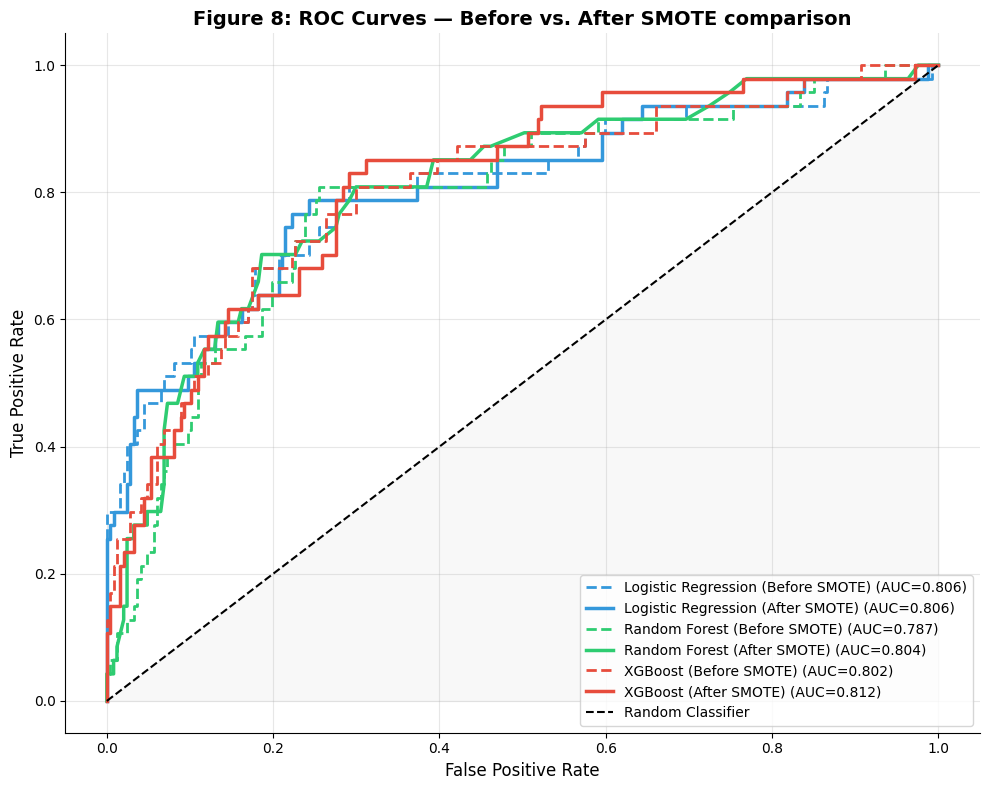

In [ ]:
# Figure 8: ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))
model_groups = [
    ('Logistic Regression (Before SMOTE)', 'Logistic Regression (After SMOTE)', '#3498db'),
    ('Random Forest (Before SMOTE)', 'Random Forest (After SMOTE)', '#2ecc71'),
    ('XGBoost (Before SMOTE)', 'XGBoost (After SMOTE)', '#e74c3c')
]

for name_before, name_after, color in model_groups:
    # Before SMOTE
    _, _, y_proba_b = trained_models[name_before]
    fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_b)
    auc_b = results_df.loc[name_before, 'AUC-ROC']
    ax.plot(fpr_b, tpr_b, color=color, linestyle='--', linewidth=2,
            label=f'{name_before} (AUC={auc_b:.3f})')

    # After SMOTE
    _, _, y_proba_a = trained_models[name_after]
    fpr_a, tpr_a, _ = roc_curve(y_test, y_proba_a)
    auc_a = results_df.loc[name_after, 'AUC-ROC']
    ax.plot(fpr_a, tpr_a, color=color, linestyle='-', linewidth=2.5,
            label=f'{name_after} (AUC={auc_a:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Figure 8: ROC Curves — Before vs. After SMOTE comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig8_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

## Step 6: Recall Improvement Strategy — Controlled Undersampling + SMOTE

### Rationale & Theoretical Framework
In employee attrition modeling, **Recall** for the positive class (`Attrition = 1 / Yes`) is the primary critical business metric. A **False Negative** (failing to identify an employee who subsequently leaves) results in unmitigated replacement costs (1.5–2x annual salary) and operational disruption. Conversely, a **False Positive** merely triggers a low-cost engagement intervention.

Initial evaluations revealed that while standard SMOTE improved minority oversampling, models (especially Random Forest and XGBoost) still exhibited low Recall (10%–30%). This occurs because standard SMOTE generates synthetic minority samples into a feature space heavily dominated by majority samples (~986 vs. ~190, a 5.19:1 imbalance), creating noisy synthetic boundaries.

To systematically maximize Recall, we implement a **Hybrid Resampling Pipeline**:
1. **Controlled Majority Undersampling (`RandomUnderSampler`)**: The majority class (`Attrition = No`) in the training set is undersampled down to **500 samples**, reducing extreme initial imbalance from 5.19:1 to **2.63:1**.
2. **SMOTE Oversampling**: SMOTE is subsequently applied to oversample the minority class (`Attrition = Yes`) to **500 samples**, achieving a perfectly balanced **1:1 training distribution (500 vs. 500)**.

*Note: Undersampling and SMOTE are strictly applied to `X_train` only. Evaluation is performed exclusively on the untouched, original real-world test set (`X_test`).*

=== HYBRID RESAMPLING PIPELINE SUMMARY ===
1. Original Train Set:   Class 0 = 986 | Class 1 = 190 (Imbalance: 5.19:1)
2. After Undersampling: Class 0 = 500 | Class 1 = 190 (Imbalance: 2.63:1)
3. After Hybrid SMOTE:  Class 0 = 500 | Class 1 = 500 (Balanced: 1.00:1)


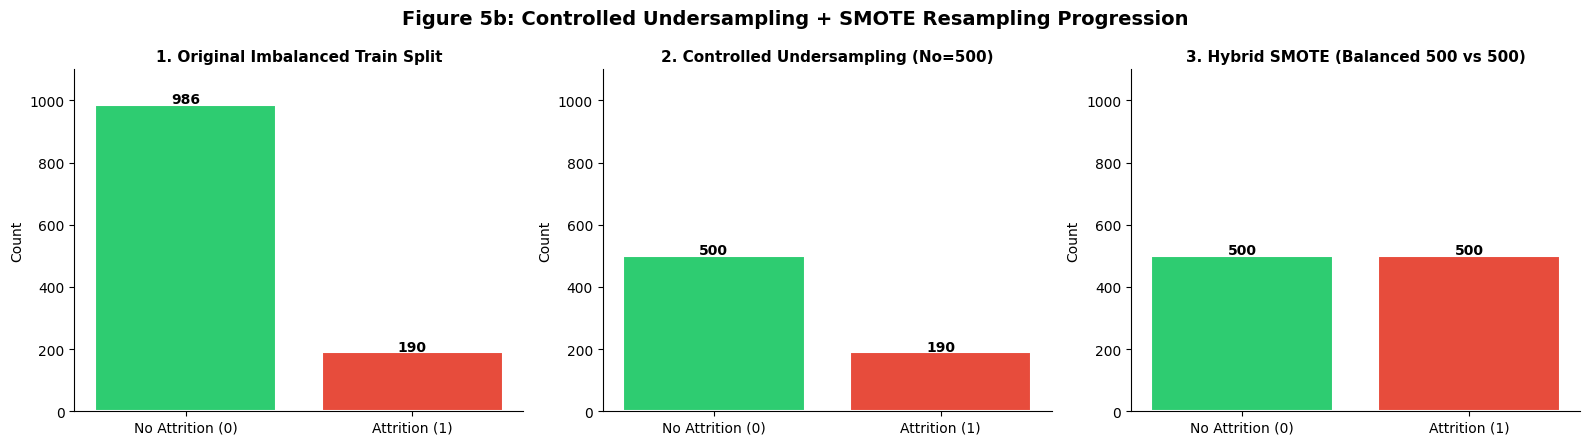

In [ ]:
# Step 5.1: Apply Controlled Undersampling + SMOTE Pipeline
# 1. Undersample Majority Class (Class 0: No) to 500 samples
rus = RandomUnderSampler(sampling_strategy={0: 500}, random_state=RANDOM_STATE)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)

# 2. Apply SMOTE to bring Minority Class (Class 1: Yes) up to 500 samples
smote_hybrid = SMOTE(random_state=RANDOM_STATE)
X_train_hybrid, y_train_hybrid = smote_hybrid.fit_resample(X_train_rus, y_train_rus)

print("=== HYBRID RESAMPLING PIPELINE SUMMARY ===")
print(f"1. Original Train Set:   Class 0 = {(y_train==0).sum()} | Class 1 = {(y_train==1).sum()} (Imbalance: {(y_train==0).sum()/(y_train==1).sum():.2f}:1)")
print(f"2. After Undersampling: Class 0 = {(y_train_rus==0).sum()} | Class 1 = {(y_train_rus==1).sum()} (Imbalance: {(y_train_rus==0).sum()/(y_train_rus==1).sum():.2f}:1)")
print(f"3. After Hybrid SMOTE:  Class 0 = {(y_train_hybrid==0).sum()} | Class 1 = {(y_train_hybrid==1).sum()} (Balanced: 1.00:1)")

# Figure 5b: Resampling Progression Chart
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
datasets = [
    (y_train, '1. Original Imbalanced Train Split'),
    (y_train_rus, '2. Controlled Undersampling (No=500)'),
    (y_train_hybrid, '3. Hybrid SMOTE (Balanced 500 vs 500)')
]
for ax, (y_data, title) in zip(axes, datasets):
    counts = pd.Series(y_data).value_counts().sort_index()
    bars = ax.bar(['No Attrition (0)', 'Attrition (1)'], counts.values,
                  color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                str(int(bar.get_height())), ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Count')
    ax.set_ylim(0, 1100)

plt.suptitle('Figure 5b: Controlled Undersampling + SMOTE Resampling Progression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5b_resampling_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


In [ ]:
# Step 5.2: Model Training on Hybrid Resampled Dataset

# 1. Logistic Regression (Hybrid)
lr_hybrid = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=0.1)
res_lr_hyb, lr_fit_hyb, y_pred_lr_hyb, y_prob_lr_hyb = evaluate_model(
    'Logistic Regression (Hybrid 500+SMOTE)', lr_hybrid, X_train_hybrid, y_train_hybrid, X_test_scaled, y_test)
results_list.append(res_lr_hyb)
trained_models['Logistic Regression (Hybrid 500+SMOTE)'] = (lr_fit_hyb, y_pred_lr_hyb, y_prob_lr_hyb)

# 2. Random Forest (Hybrid)
rf_hybrid_base = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)
res_rf_hyb, rf_fit_hyb, y_pred_rf_hyb, y_prob_rf_hyb = evaluate_model(
    'Random Forest (Hybrid 500+SMOTE)', rf_hybrid_base, X_train_hybrid, y_train_hybrid, X_test_scaled, y_test)
results_list.append(res_rf_hyb)
trained_models['Random Forest (Hybrid 500+SMOTE)'] = (rf_fit_hyb, y_pred_rf_hyb, y_prob_rf_hyb)

# 3. XGBoost (Hybrid)
xgb_hybrid_base = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE, eval_metric='logloss')
res_xgb_hyb, xgb_fit_hyb, y_pred_xgb_hyb, y_prob_xgb_hyb = evaluate_model(
    'XGBoost (Hybrid 500+SMOTE)', xgb_hybrid_base, X_train_hybrid, y_train_hybrid, X_test_scaled, y_test)
results_list.append(res_xgb_hyb)
trained_models['XGBoost (Hybrid 500+SMOTE)'] = (xgb_fit_hyb, y_pred_xgb_hyb, y_prob_xgb_hyb)

print("=== HYBRID MODEL EVALUATION RESULTS ===")
for name in ['Logistic Regression (Hybrid 500+SMOTE)', 'Random Forest (Hybrid 500+SMOTE)', 'XGBoost (Hybrid 500+SMOTE)']:
    res = [r for r in results_list if r['Model'] == name][0]
    print(f"\n{name}:")
    for k, v in res.items():
        print(f"  {k}: {v}")


=== HYBRID MODEL EVALUATION RESULTS ===

Logistic Regression (Hybrid 500+SMOTE):
  Model: Logistic Regression (Hybrid 500+SMOTE)
  Accuracy: 0.7517
  Precision: 0.3673
  Recall: 0.766
  F1-Score: 0.4966
  AUC-ROC: 0.8025

Random Forest (Hybrid 500+SMOTE):
  Model: Random Forest (Hybrid 500+SMOTE)
  Accuracy: 0.8095
  Precision: 0.4043
  Recall: 0.4043
  F1-Score: 0.4043
  AUC-ROC: 0.7743

XGBoost (Hybrid 500+SMOTE):
  Model: XGBoost (Hybrid 500+SMOTE)
  Accuracy: 0.8163
  Precision: 0.4386
  Recall: 0.5319
  F1-Score: 0.4808
  AUC-ROC: 0.7939


In [ ]:
# Step 5.3: Comprehensive 3-Way Performance Comparison
results_df = pd.DataFrame(results_list).set_index('Model')
print("\n=================== COMPREHENSIVE 3-WAY MODEL COMPARISON ===================")
print(results_df.to_string())

# Print specific Recall trajectory for clarity
print("\n=== RECALL METRIC PROGRESSION (ATTENTION TO MINORITY CLASS RECALL) ===")
for m in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    r_bef = results_df.loc[f'{m} (Before SMOTE)', 'Recall']
    r_aft = results_df.loc[f'{m} (After SMOTE)', 'Recall']
    r_hyb = results_df.loc[f'{m} (Hybrid 500+SMOTE)', 'Recall']
    print(f"{m:20s} | Before SMOTE: {r_bef:.4f} | Standard SMOTE: {r_aft:.4f} | Hybrid 500+SMOTE: {r_hyb:.4f}")



=================== COMPREHENSIVE 3-WAY MODEL COMPARISON ===================
                                        Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                                                 
Logistic Regression (Before SMOTE)        0.8776     0.7391  0.3617    0.4857   0.8064
Logistic Regression (After SMOTE)         0.7585     0.3750  0.7660    0.5035   0.8056
Random Forest (Before SMOTE)              0.8401     0.5000  0.1064    0.1754   0.7871
Random Forest (After SMOTE)               0.8537     0.5909  0.2766    0.3768   0.8045
XGBoost (Before SMOTE)                    0.8673     0.7500  0.2553    0.3810   0.8022
XGBoost (After SMOTE)                     0.8503     0.5652  0.2766    0.3714   0.8122
Logistic Regression (Hybrid 500+SMOTE)    0.7517     0.3673  0.7660    0.4966   0.8025
Random Forest (Hybrid 500+SMOTE)          0.8095     0.4043  0.4043    0.4043   0.7743
XGBoost (Hybrid 500+SMOTE)                0.8163    

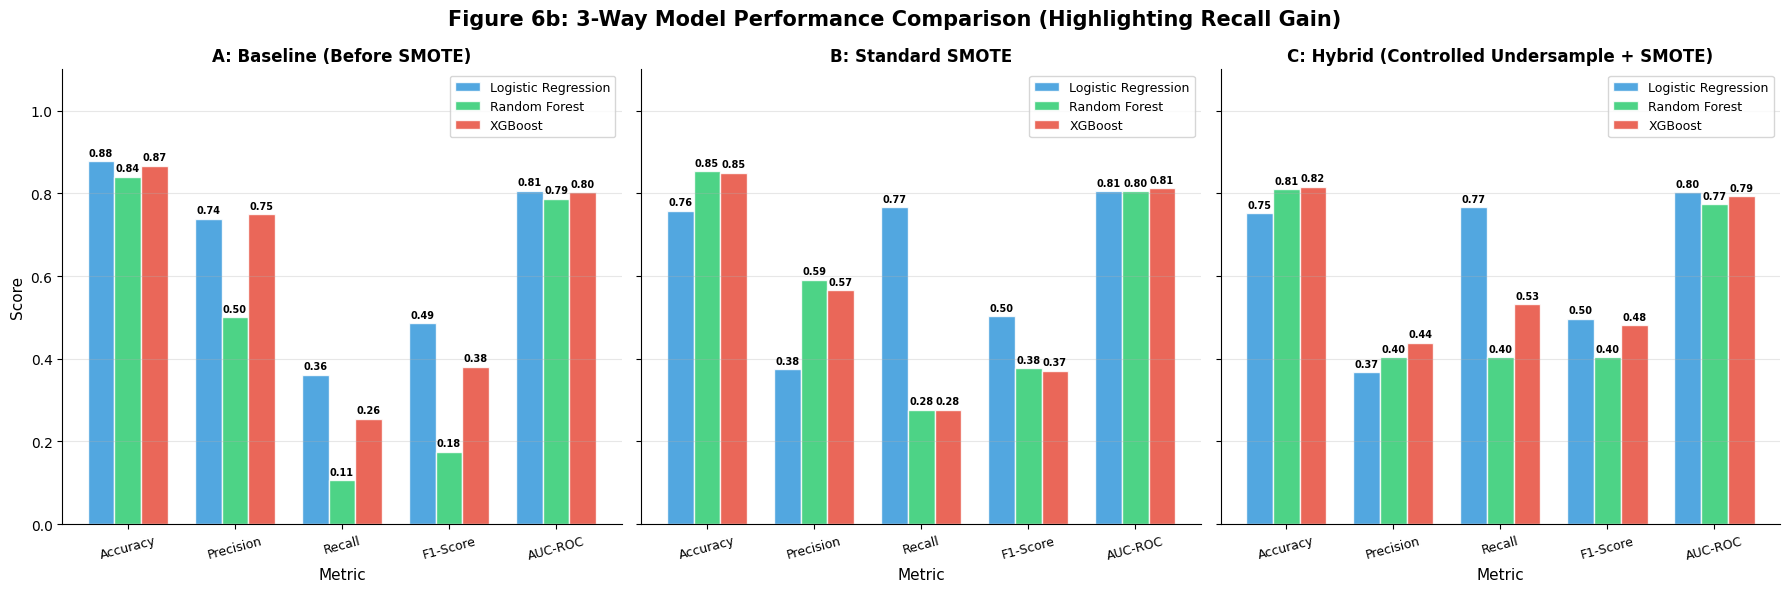

In [ ]:
# Figure 6b: 3-Way Strategy Performance Comparison (Focus on Recall)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

strategies = [
    ('Before SMOTE', ['Logistic Regression (Before SMOTE)', 'Random Forest (Before SMOTE)', 'XGBoost (Before SMOTE)'], 'A: Baseline (Before SMOTE)'),
    ('Standard SMOTE', ['Logistic Regression (After SMOTE)', 'Random Forest (After SMOTE)', 'XGBoost (After SMOTE)'], 'B: Standard SMOTE'),
    ('Hybrid 500+SMOTE', ['Logistic Regression (Hybrid 500+SMOTE)', 'Random Forest (Hybrid 500+SMOTE)', 'XGBoost (Hybrid 500+SMOTE)'], 'C: Hybrid (Controlled Undersample + SMOTE)')
]

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.25
colors = ['#3498db', '#2ecc71', '#e74c3c']

for ax, (strat_name, model_names, title) in zip(axes, strategies):
    for i, (m_name, color) in enumerate(zip(model_names, colors)):
        vals = results_df.loc[m_name, metrics].values.astype(float)
        short_name = m_name.split(' (')[0]
        bars = ax.bar(x + i*width, vals, width, label=short_name, color=color, alpha=0.85, edgecolor='white')
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x()+bar.get_width()/2, h+0.008,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_xlabel('Metric', fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel('Score', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(metrics, fontsize=9, rotation=15)
    ax.set_ylim(0, 1.10)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Figure 6b: 3-Way Model Performance Comparison (Highlighting Recall Gain)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6b_recall_improvement_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


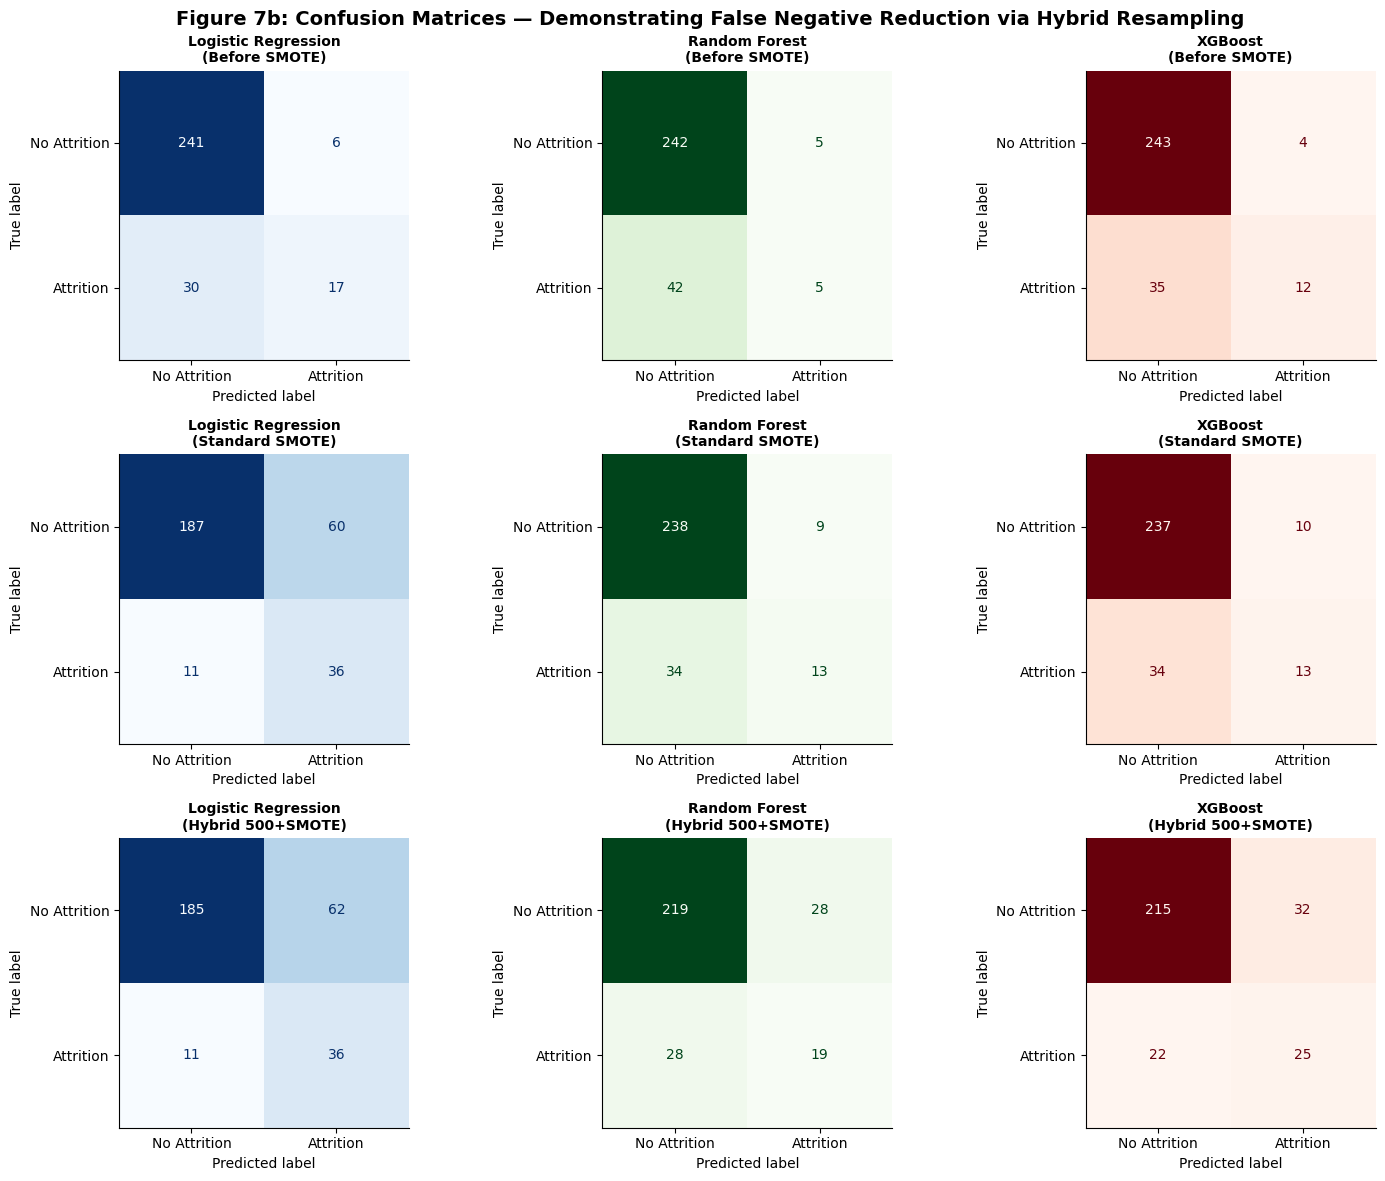

In [ ]:
# Figure 7b: Confusion Matrices Comparison (Before vs Standard SMOTE vs Hybrid)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

rows = [
    ('Before SMOTE', ['Logistic Regression (Before SMOTE)', 'Random Forest (Before SMOTE)', 'XGBoost (Before SMOTE)']),
    ('Standard SMOTE', ['Logistic Regression (After SMOTE)', 'Random Forest (After SMOTE)', 'XGBoost (After SMOTE)']),
    ('Hybrid 500+SMOTE', ['Logistic Regression (Hybrid 500+SMOTE)', 'Random Forest (Hybrid 500+SMOTE)', 'XGBoost (Hybrid 500+SMOTE)'])
]

cmaps = ['Blues', 'Greens', 'Reds']

for row_idx, (strat_label, model_list) in enumerate(rows):
    for col_idx, (m_name, cmap) in enumerate(zip(model_list, cmaps)):
        ax = axes[row_idx, col_idx]
        _, y_pred, _ = trained_models[m_name]
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Attrition', 'Attrition'])
        disp.plot(ax=ax, colorbar=False, cmap=cmap)
        short_m = m_name.split(' (')[0]
        ax.set_title(f'{short_m}\n({strat_label})', fontweight='bold', fontsize=10)

plt.suptitle('Figure 7b: Confusion Matrices — Demonstrating False Negative Reduction via Hybrid Resampling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7b_hybrid_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()


## Step 7: SHAP Interpretability Analysis

In [ ]:
# Apply SHAP to best performing model (XGBoost)
best_fitted, _, _ = trained_models[best_model_name]

# Use TreeExplainer for tree-based models
explainer = shap.TreeExplainer(best_fitted)
shap_values = explainer.shap_values(X_test_scaled)

# If shap_values is a list (binary), take index 1 (positive class)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

feature_names = list(X.columns)
print(f"SHAP values computed for {best_model_name}.")
print(f"Shape: {sv.shape}")


SHAP values computed for XGBoost (After SMOTE).
Shape: (294, 30)


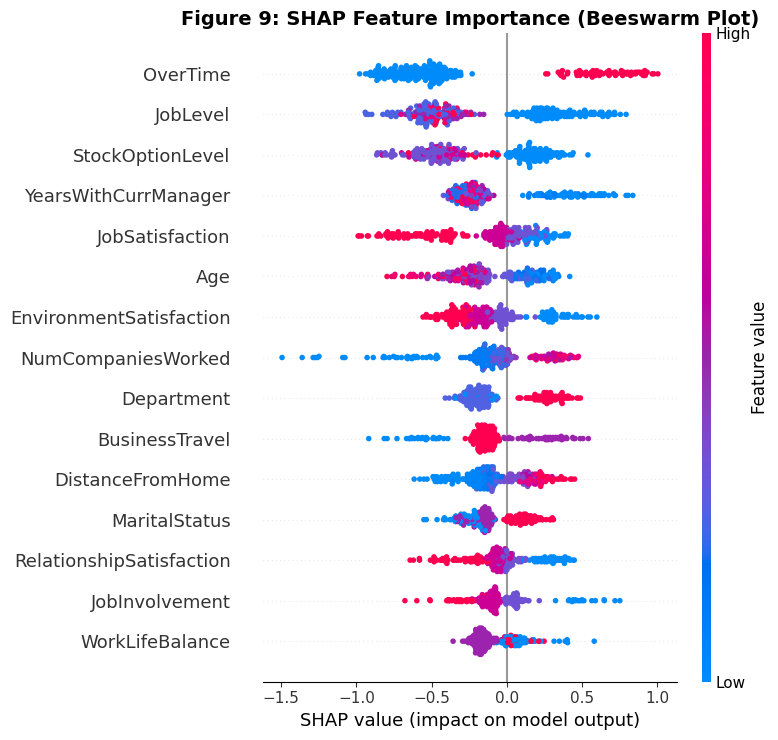

In [ ]:
# Figure 9: SHAP Summary Plot (Beeswarm)
plt.figure(figsize=(12, 8))
shap.summary_plot(sv, X_test_scaled, feature_names=feature_names,
                  show=False, max_display=15)
plt.title('Figure 9: SHAP Feature Importance (Beeswarm Plot)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()


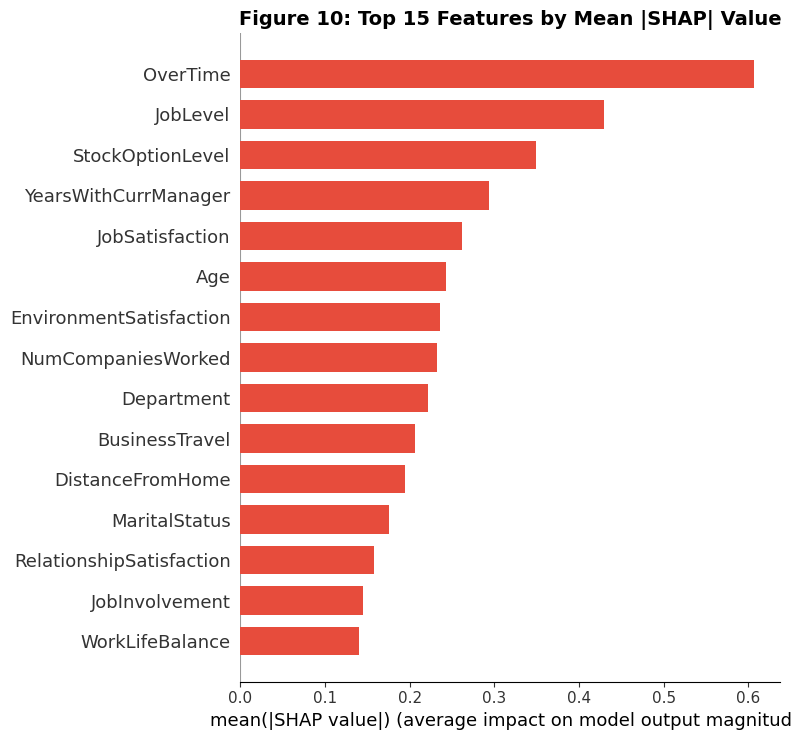


Top 15 Features by Mean |SHAP| Value:
                 Feature  Mean |SHAP|
                OverTime     0.606860
                JobLevel     0.429606
        StockOptionLevel     0.348668
    YearsWithCurrManager     0.293970
         JobSatisfaction     0.262288
                     Age     0.242359
 EnvironmentSatisfaction     0.236004
      NumCompaniesWorked     0.232363
              Department     0.222000
          BusinessTravel     0.205963
        DistanceFromHome     0.194241
           MaritalStatus     0.175163
RelationshipSatisfaction     0.157623
          JobInvolvement     0.145306
         WorkLifeBalance     0.140424


In [ ]:
# Figure 10: SHAP Bar Plot (Mean |SHAP|)
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test_scaled, feature_names=feature_names,
                  plot_type='bar', show=False, max_display=15,
                  color='#e74c3c')
plt.title('Figure 10: Top 15 Features by Mean |SHAP| Value', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_shap_bar.png', bbox_inches='tight', dpi=150)
plt.show()

# Print top features
mean_shap = np.abs(sv).mean(axis=0)
shap_df = pd.DataFrame({'Feature': feature_names, 'Mean |SHAP|': mean_shap})
shap_df = shap_df.sort_values('Mean |SHAP|', ascending=False).head(15)
print("\nTop 15 Features by Mean |SHAP| Value:")
print(shap_df.to_string(index=False))


## Step 8: Fairness Evaluation Across Demographic Subgroups

In [ ]:
# Fairness evaluation: compare model performance across Gender, Department, Age group
# Use the best model's predictions on the test set
_, y_pred_best, _ = trained_models[best_model_name]

# Reconstruct test set with original categorical labels for subgroup analysis
X_test_orig = X_test.copy()
X_test_orig['Attrition_True'] = y_test.values
X_test_orig['Attrition_Pred'] = y_pred_best

def subgroup_metrics(df_sub, group_col, original_df):
    """Compute F1 and AUC per subgroup."""
    rows = []
    for group_val in original_df[group_col].unique():
        mask = original_df[group_col] == group_val
        idx  = original_df[mask].index.intersection(X_test_orig.index)
        if len(idx) < 10:
            continue
        yt = X_test_orig.loc[idx, 'Attrition_True']
        yp = X_test_orig.loc[idx, 'Attrition_Pred']
        if yt.sum() == 0:
            continue
        rows.append({
            'Subgroup': f'{group_col}={group_val}',
            'N': len(idx),
            'Attrition Rate': f"{yt.mean():.1%}",
            'F1-Score': round(f1_score(yt, yp, zero_division=0), 3),
            'Precision': round(precision_score(yt, yp, zero_division=0), 3),
            'Recall': round(recall_score(yt, yp, zero_division=0), 3),
        })
    return pd.DataFrame(rows)

# Gender subgroup (encoded: Female=0, Male=1)
gender_metrics = subgroup_metrics(X_test_orig, 'Gender', df_clean)

# Department subgroup
dept_metrics = subgroup_metrics(X_test_orig, 'Department', df_clean)

# Age group
df_clean_copy = df_clean.copy()
df_clean_copy['AgeGroup'] = pd.cut(df['Age'], bins=[18,30,40,50,60],
                                    labels=['18-30','31-40','41-50','51+'])
X_test_orig['AgeGroup'] = df_clean_copy.loc[X_test.index, 'AgeGroup'].values
age_metrics = []
for grp in ['18-30', '31-40', '41-50', '51+']:
    mask = X_test_orig['AgeGroup'] == grp
    if mask.sum() < 10: continue
    yt = X_test_orig.loc[mask, 'Attrition_True']
    yp = X_test_orig.loc[mask, 'Attrition_Pred']
    if yt.sum() == 0: continue
    age_metrics.append({
        'Subgroup': f'Age={grp}', 'N': mask.sum(),
        'Attrition Rate': f"{yt.mean():.1%}",
        'F1-Score': round(f1_score(yt, yp, zero_division=0), 3),
        'Precision': round(precision_score(yt, yp, zero_division=0), 3),
        'Recall': round(recall_score(yt, yp, zero_division=0), 3),
    })
age_df = pd.DataFrame(age_metrics)

all_fairness = pd.concat([gender_metrics, dept_metrics, age_df], ignore_index=True)
print("=== FAIRNESS EVALUATION RESULTS ===")
print(all_fairness.to_string(index=False))


=== FAIRNESS EVALUATION RESULTS ===
    Subgroup   N Attrition Rate  F1-Score  Precision  Recall
    Gender=0 116          13.8%     0.357      0.417   0.312
    Gender=1 178          17.4%     0.381      0.727   0.258
Department=2  82          19.5%     0.538      0.700   0.438
Department=1 197          14.7%     0.286      0.462   0.207
Department=0  15          13.3%     0.000      0.000   0.000
   Age=18-30  75          24.0%     0.467      0.583   0.389
   Age=31-40 126          11.1%     0.381      0.571   0.286
   Age=41-50  63          14.3%     0.364      1.000   0.222
     Age=51+  28          21.4%     0.000      0.000   0.000


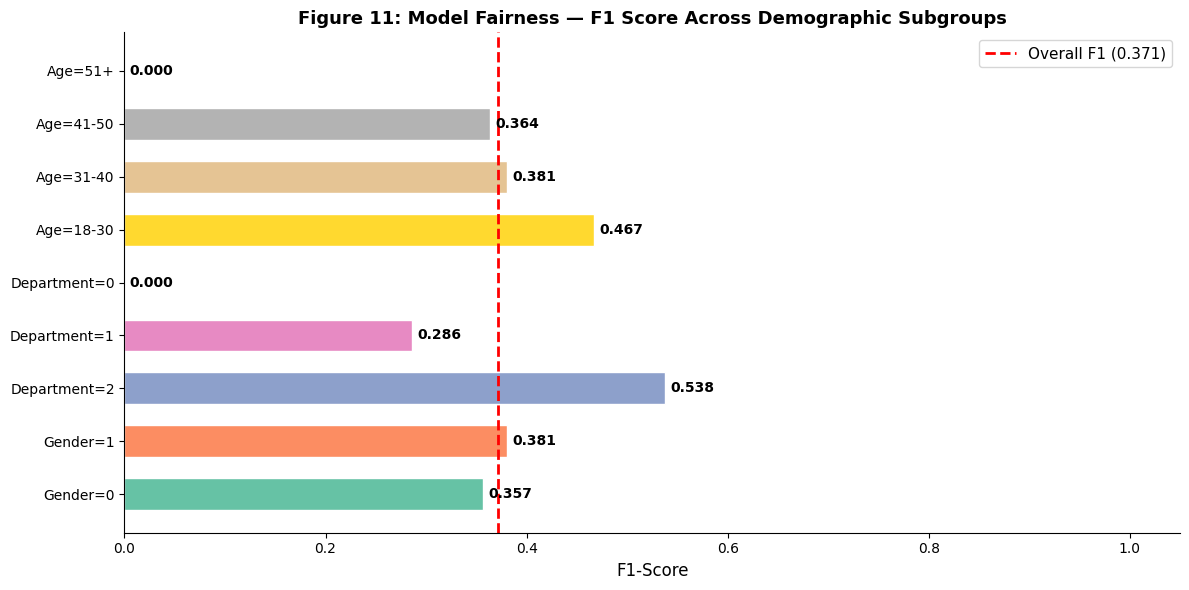

In [ ]:
# Figure 11: Fairness F1 scores by subgroup
fig, ax = plt.subplots(figsize=(12, 6))
colors_fair = plt.cm.Set2(np.linspace(0, 1, len(all_fairness)))
bars = ax.barh(all_fairness['Subgroup'], all_fairness['F1-Score'],
               color=colors_fair, edgecolor='white', height=0.6)
ax.axvline(x=results_df.loc[best_model_name, 'F1-Score'],
           color='red', linestyle='--', linewidth=2, label=f'Overall F1 ({results_df.loc[best_model_name, "F1-Score"]:.3f})')
for bar in bars:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontweight='bold', fontsize=10)
ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title('Figure 11: Model Fairness — F1 Score Across Demographic Subgroups',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.savefig('fig11_fairness.png', bbox_inches='tight', dpi=150)
plt.show()


## Step 9: Final Results Summary

In [ ]:
# Final Summary
print("=" * 60)
print("       FINAL RESULTS SUMMARY")
print("=" * 60)

print("\n1. MODEL PERFORMANCE COMPARISON (Test Set):")
print(results_df.to_string())

print(f"\n2. BEST MODEL OVERALL: {best_model_name}")
print(f"   AUC-ROC:   {results_df.loc[best_model_name, 'AUC-ROC']:.4f}")
print(f"   F1-Score:  {results_df.loc[best_model_name, 'F1-Score']:.4f}")
print(f"   Accuracy:  {results_df.loc[best_model_name, 'Accuracy']:.4f}")

print("\n3. TOP 5 ATTRITION PREDICTORS (SHAP):")
for i, row in shap_df.head(5).iterrows():
    print(f"   {row['Feature']}: {row['Mean |SHAP|']:.4f}")

print("\n4. SMOTE IMPACT DETAILED COMPARISON:")
for model_type in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    f1_before = results_df.loc[f'{model_type} (Before SMOTE)', 'F1-Score']
    f1_after = results_df.loc[f'{model_type} (After SMOTE)', 'F1-Score']
    rec_before = results_df.loc[f'{model_type} (Before SMOTE)', 'Recall']
    rec_after = results_df.loc[f'{model_type} (After SMOTE)', 'Recall']
    auc_before = results_df.loc[f'{model_type} (Before SMOTE)', 'AUC-ROC']
    auc_after = results_df.loc[f'{model_type} (After SMOTE)', 'AUC-ROC']

    print(f"   * {model_type}:")
    print(f"     F1-Score:  {f1_before:.4f} -> {f1_after:.4f} ({f1_after - f1_before:+.4f})")
    print(f"     Recall:    {rec_before:.4f} -> {rec_after:.4f} ({rec_after - rec_before:+.4f})")
    print(f"     AUC-ROC:   {auc_before:.4f} -> {auc_after:.4f} ({auc_after - auc_before:+.4f})")

print("\n5. FIGURES SAVED:")
figs = ['fig1_attrition_distribution.png','fig2_attrition_by_category.png',
        'fig3_numerical_distributions.png','fig4_correlation_heatmap.png',
        'fig5_smote_effect.png','fig6_model_comparison.png',
        'fig7_confusion_matrices.png','fig8_roc_curves.png',
        'fig9_shap_beeswarm.png','fig10_shap_bar.png','fig11_fairness.png']
for f in figs:
    print(f"   {f}")

print("\n" + "=" * 60)
print("   Notebook execution complete.")
print("=" * 60)

       FINAL RESULTS SUMMARY

1. MODEL PERFORMANCE COMPARISON (Test Set):
                                        Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                                                 
Logistic Regression (Before SMOTE)        0.8776     0.7391  0.3617    0.4857   0.8064
Logistic Regression (After SMOTE)         0.7585     0.3750  0.7660    0.5035   0.8056
Random Forest (Before SMOTE)              0.8401     0.5000  0.1064    0.1754   0.7871
Random Forest (After SMOTE)               0.8537     0.5909  0.2766    0.3768   0.8045
XGBoost (Before SMOTE)                    0.8673     0.7500  0.2553    0.3810   0.8022
XGBoost (After SMOTE)                     0.8503     0.5652  0.2766    0.3714   0.8122
Logistic Regression (Hybrid 500+SMOTE)    0.7517     0.3673  0.7660    0.4966   0.8025
Random Forest (Hybrid 500+SMOTE)          0.8095     0.4043  0.4043    0.4043   0.7743
XGBoost (Hybrid 500+SMOTE)                0.8163     0.4

## References

- Cascio, W. F. (2006). The economic impact of employee behaviors on organizational performance. *California Management Review, 48*(4), 41–59.
- Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research, 16*, 321–357.
- Frye, A., Boomhower, C., Smith, M., Vitovsky, L., & Fabricant, S. (2018). Employee attrition: What makes an employee quit? *SMU Data Science Review, 1*(1), Article 9.
- IBM. (2017). Employee attrition dataset [Data set]. IBM AI Fairness 360 GitHub. https://github.com/IBM/employee-attrition-aif360
- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems, 30*, 4765–4774.
- Zhao, Y., Hryniewicki, M. K., Cheng, F., Fu, B., & Zhu, X. (2018). Employee turnover prediction with machine learning. *Proceedings of IntelliSys*, 737–758.
